# Set up

## Change working directory

In [1]:
%cd ../

C:\Users\Skylar\Downloads\tools


## Install packages

In [2]:
# Placeholder

## Import development libraries

In [3]:
import ipytest
import pytest

ipytest.autoconfig(rewrite_asserts=False)

## Import other libraries

In [4]:
import typing
import warnings

import lifelines
import numpy as np
import pandas as pd
import toolz as tz
from matplotlib import pyplot as plt

## Declare constants

In [5]:
module: str = "lifelines"

# Define get_durations_and_events_from_datetimes

## Define

In [6]:
def get_durations_and_events_from_datetimes(
    data: pd.DataFrame,
    start_column: str,
    end_column: str,
    raise_missing_starts: bool = True,
    raise_ends_before_starts: bool = True,
    duration_column: str | None = None,
    event_column: str | None = None,
    **kwargs,
) -> pd.DataFrame:
    # Check for missing starts
    if data[start_column].isna().any():
        message: str = "Start column `%s` is missing values" % start_column
        if raise_missing_starts:
            raise ValueError(message)
        warnings.warn(message=message)
    # Check for ends before starts
    if data[end_column].lt(other=data[start_column]).any():
        message: str = "Some values of end column `%s` come before corresponding values of start column `%s`" % (
            end_column,
            start_column,
        )
        if raise_ends_before_starts:
            raise ValueError(message)
    # Compute durations and events
    duration_column: str = duration_column or "duration"
    event_column: str = event_column or "event"
    fn: typing.Callable = lambda x: x not in ["start_times", "end_times"]
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=fn, d=kwargs)
    durations: tuple[np.ndarray, np.ndarray] = lifelines.utils.datetimes_to_durations(
        start_times=data[start_column], end_times=data[end_column], **filtered_kwargs
    )
    return tz.pipe(
        zip([duration_column, event_column], durations),
        dict,
        tz.partial(pd.DataFrame, index=data.index),
        lambda x: data.join(other=x, how="left", validate="1:1"),
    )

## Demonstrate

In [7]:
periods: int = 5
starts: list = pd.date_range(start="2020-01-01", periods=periods).tolist() + [pd.NaT]
start: pd.Timestamp = starts[0] - pd.Timedelta(value=1, unit="D")
ends: list = pd.date_range(start=start, periods=periods - 1, freq="ME").tolist() + [pd.NaT] * 2
data = pd.DataFrame(data={"starts": starts, "ends": ends})
# Note edge cases triggering warnings on first and last lines
get_durations_and_events_from_datetimes(
    data=data, start_column="starts", end_column="ends", raise_missing_starts=False, raise_ends_before_starts=False
)

C:\Users\Skylar\AppData\Local\Temp\ipykernel_1528\3729054539.py:16: UserWarning: Start column `starts` is missing values
  warnings.warn(message=message)
C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\lifelines\utils\__init__.py:693: UserWarning: Warning: some values of start_times are after end_times.

  warnings.warn("Warning: some values of start_times are after end_times.\n", UserWarning)


,starts,ends,duration,event
0,2020-01-01,2019-12-31,-1.000000e+00,True
1,2020-01-02,2020-01-31,2.900000e+01,True
2,2020-01-03,2020-02-29,5.700000e+01,True
3,2020-01-04,2020-03-31,8.700000e+01,True
4,2020-01-05,NaT,2.313000e+03,False
5,NaT,NaT,-9.223372e+18,False


## Test

In [8]:
%%ipytest

# Helper(s)
def make_data(starts: list, ends: list) -> pd.DataFrame:
    return pd.DataFrame(data={'starts': starts, 'ends': ends})

# Deterministic test(s)
@pytest.mark.parametrize("raise_missing_starts", [False, True])
def test_missing_starts(raise_missing_starts: bool) -> None:
    starts: list = [pd.NaT]
    ends: list = [pd.Timestamp("2020-01-03")]
    data: pd.DataFrame = make_data(starts=starts, ends=ends)
    shared_args = dict(data=data, start_column="starts", end_column="ends", raise_missing_starts=raise_missing_starts)
    if raise_missing_starts:
        with pytest.raises(expected_exception=ValueError):
            out: pd.DataFrame = get_durations_and_events_from_datetimes(**shared_args)
    else:
        with pytest.warns(expected_warning=UserWarning):
            out: pd.DataFrame = get_durations_and_events_from_datetimes(**shared_args)

@pytest.mark.parametrize("raise_ends_before_starts", [False, True])
def test_ends_before_starts(raise_ends_before_starts: bool) -> None:
    starts: list = [pd.Timestamp(ts_input="2020-01-05")]
    ends: list = [pd.Timestamp(ts_input="2020-01-03")]
    data: pd.DataFrame = make_data(starts=starts, ends=ends)
    shared_args = dict(data=data, start_column="starts", end_column="ends", raise_ends_before_starts=raise_ends_before_starts)
    if raise_ends_before_starts:
        with pytest.raises(expected_exception=ValueError):
            out: pd.DataFrame = get_durations_and_events_from_datetimes(**shared_args)
    else:
        with pytest.warns(expected_warning=UserWarning):
            out: pd.DataFrame = get_durations_and_events_from_datetimes(**shared_args)

def test_periods() -> None:
    starts: list = [pd.Period(value="2020-01-01")]
    ends: list = [pd.Period(value="2020-01-03")]
    data: pd.DataFrame = make_data(starts=starts, ends=ends)
    shared_args = dict(data=data, start_column="starts", end_column="ends")
    with pytest.raises(expected_exception=TypeError):
        out: pd.DataFrame = get_durations_and_events_from_datetimes(**shared_args)

.....                                                                                        [100%]
5 passed in 0.32s


# Define plot_low_cardinality_feature

## Define

In [9]:
def plot_low_cardinality_feature(
    data: pd.DataFrame,
    feature_column: str,
    duration_column: str,
    event_column: str,
    ax: plt.Axes | None = None,
    Fitter: typing.Any = lifelines.KaplanMeierFitter,
    init_args: dict | None = None,
    fit_args: dict | None = None,
    plot_args: dict | None = None,
    add_at_risk_counts_args: dict | None = None,
) -> tuple[plt.Axes, list]:
    ax: plt.Axes = ax or plt.subplot(1, 1, 1)
    fitters: list = []
    for value in data[feature_column].drop_duplicates().sort_values():  # type: typing.Any
        filtered_data: pd.DataFrame = data.loc[lambda x: x[feature_column].eq(other=value), :]
        durations: pd.Series = filtered_data[duration_column]
        events: pd.Series = filtered_data[event_column]
        filtered_init_args: dict = tz.keyfilter(predicate=lambda x: x != "label", d=init_args or {})
        fitter: typing.Any = Fitter(label=value, **filtered_init_args)
        filtered_fit_args: dict = tz.keyfilter(
            predicate=lambda x: x not in ["durations", "event_observed"], d=fit_args or {}
        )
        fitters.append(fitter.fit(durations=durations, event_observed=events, **filtered_fit_args))
        filtered_plot_args: dict = tz.keyfilter(predicate=lambda x: x != "ax", d=plot_args or {})
        fitters[-1].plot(ax=ax, **filtered_plot_args)
    filtered_add_at_risk_counts_args: dict = tz.keyfilter(
        predicate=lambda x: x != "ax", d=add_at_risk_counts_args or {}
    )
    lifelines.plotting.add_at_risk_counts(*fitters, ax=ax, **filtered_add_at_risk_counts_args)
    return ax, fitters

## Demonstrate

,week,arrest,fin,age,race,wexp,mar,paro,prio,age_binned
0,20,1,0,27,1,0,0,1,3,"(23.0, 27.0]"
1,17,1,0,18,1,0,0,1,8,"(16.999, 20.0]"
2,25,1,0,19,0,1,0,1,13,"(16.999, 20.0]"
3,52,0,1,23,1,1,1,1,1,"(20.0, 23.0]"
4,52,0,0,19,0,1,0,1,3,"(16.999, 20.0]"
...,...,...,...,...,...,...,...,...,...,...
427,52,0,1,31,0,1,0,1,3,"(27.0, 44.0]"
428,52,0,0,20,1,0,0,1,1,"(16.999, 20.0]"
429,52,0,1,20,1,1,1,1,1,"(16.999, 20.0]"
430,52,0,0,29,1,1,0,1,3,"(27.0, 44.0]"


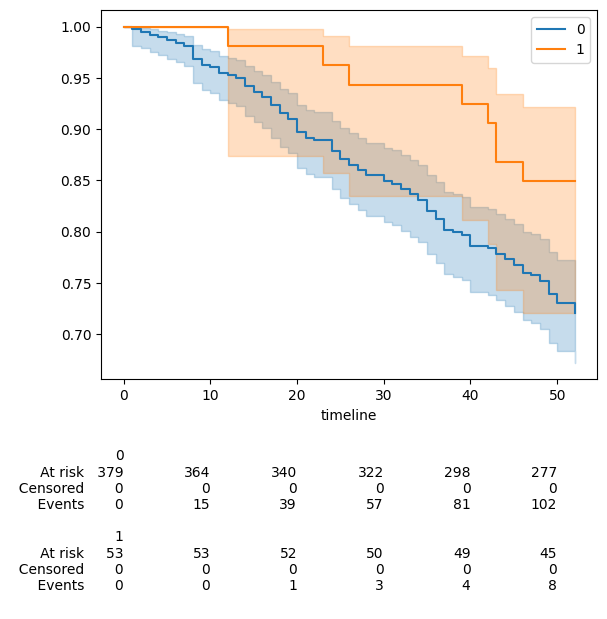

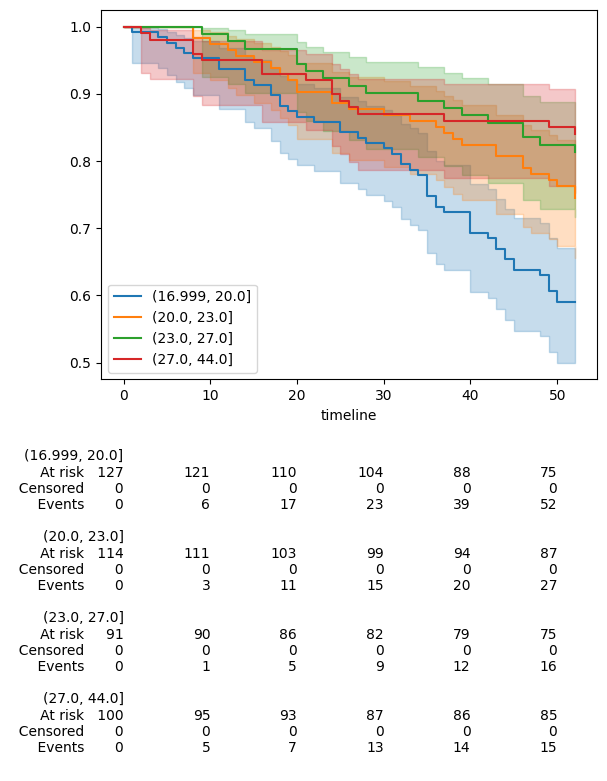

In [10]:
data: pd.DataFrame = lifelines.datasets.load_rossi().assign(**{"age_binned": lambda x: pd.qcut(x=x["age"], q=4)})
display(data)
for feature_column in ["mar", "age_binned"]:
    args = dict(data=data, feature_column=feature_column, duration_column="week", event_column="arrest")
    plot_low_cardinality_feature(**args)
    plt.show()
    plt.close()

## Test

.                                                                                            [100%]
======================================== warnings summary =========================================
t_e4aa48ccf5e04580807e292dcc9f25ac.py::test_missing_feature_values
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\lifelines\fitters\kaplan_meier_fitter.py:450: DeprecationWarning: The `plot` function is deprecated, and will be removed in future versions. Use `plot_survival_function`
    warnings.warn(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
1 passed, 1 warning in 0.04s


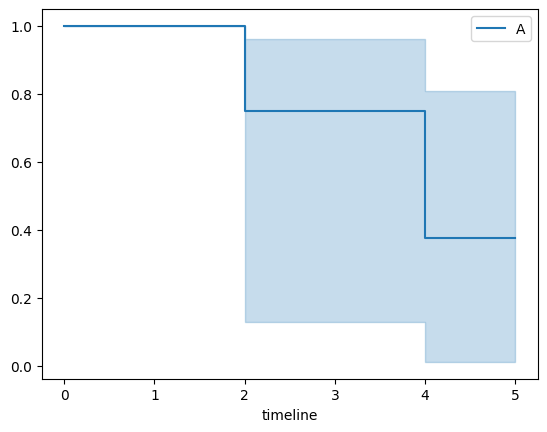

In [11]:
%%ipytest

def test_missing_feature_values() -> None:
    data = pd.DataFrame(data={'feature': ['A'] * 5 + [None],'duration': range(1, 7),'event': np.tile(A=[0, 1], reps=3)})
    with pytest.raises(expected_exception=ValueError):
        plot_low_cardinality_feature(data=data, feature_column="feature", duration_column="duration", event_column="event")

# Write module

## Write

In [12]:
module_path: str = "src/tools/%s.py" % module

In [13]:
%%file $module_path

import typing
import warnings

import lifelines
import numpy as np
import pandas as pd
import toolz as tz
from matplotlib import pyplot as plt

def get_durations_and_events_from_datetimes(
    data: pd.DataFrame,
    start_column: str,
    end_column: str,
    raise_missing_starts: bool = True,
    raise_ends_before_starts: bool = True,
    duration_column: str | None = None,
    event_column: str | None = None,
    **kwargs,
) -> pd.DataFrame:
    # Check for missing starts
    if data[start_column].isna().any():
        message: str = "Start column `%s` is missing values" % start_column
        if raise_missing_starts:
            raise ValueError(message)
        warnings.warn(message=message)
    # Check for ends before starts
    if data[end_column].lt(other=data[start_column]).any():
        message: str = "Some values of end column `%s` come before corresponding values of start column `%s`" % (
            end_column,
            start_column,
        )
        if raise_ends_before_starts:
            raise ValueError(message)
    # Compute durations and events
    duration_column: str = duration_column or "duration"
    event_column: str = event_column or "event"
    fn: typing.Callable = lambda x: x not in ["start_times", "end_times"]
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=fn, d=kwargs)
    durations: tuple[np.ndarray, np.ndarray] = lifelines.utils.datetimes_to_durations(
        start_times=data[start_column], end_times=data[end_column], **filtered_kwargs
    )
    return tz.pipe(
        zip([duration_column, event_column], durations),
        dict,
        tz.partial(pd.DataFrame, index=data.index),
        lambda x: data.join(other=x, how="left", validate="1:1"),
    )

def plot_low_cardinality_feature(
    data: pd.DataFrame,
    feature_column: str,
    duration_column: str,
    event_column: str,
    ax: plt.Axes | None = None,
    Fitter: typing.Any = lifelines.KaplanMeierFitter,
    init_args: dict | None = None,
    fit_args: dict | None = None,
    plot_args: dict | None = None,
    add_at_risk_counts_args: dict | None = None,
) -> tuple[plt.Axes, list]:
    ax: plt.Axes = ax or plt.subplot(1, 1, 1)
    fitters: list = []
    for value in data[feature_column].drop_duplicates().sort_values():  # type: typing.Any
        filtered_data: pd.DataFrame = data.loc[lambda x: x[feature_column].eq(other=value), :]
        durations: pd.Series = filtered_data[duration_column]
        events: pd.Series = filtered_data[event_column]
        filtered_init_args: dict = tz.keyfilter(predicate=lambda x: x != "label", d=init_args or {})
        fitter: typing.Any = Fitter(label=value, **filtered_init_args)
        filtered_fit_args: dict = tz.keyfilter(
            predicate=lambda x: x not in ["durations", "event_observed"], d=fit_args or {}
        )
        fitters.append(fitter.fit(durations=durations, event_observed=events, **filtered_fit_args))
        filtered_plot_args: dict = tz.keyfilter(predicate=lambda x: x != "ax", d=plot_args or {})
        fitters[-1].plot(ax=ax, **filtered_plot_args)
    filtered_add_at_risk_counts_args: dict = tz.keyfilter(
        predicate=lambda x: x != "ax", d=add_at_risk_counts_args or {}
    )
    lifelines.plotting.add_at_risk_counts(*fitters, ax=ax, **filtered_add_at_risk_counts_args)
    return ax, fitters

Writing src/tools/lifelines.py


## Format

In [14]:
!ruff format $module_path

1 file reformatted


## Check with ruff

In [15]:
!ruff check $module_path

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\lifelines.py:19:5
   |
17 |     duration_column: str | None = None,
18 |     event_column: str | None = None,
19 |     **kwargs,
   |     ^^^^^^^^
20 | ) -> pd.DataFrame:
21 |     # Check for missing starts
   |

ANN401 Dynamically typed expressions (typing.Any) are disallowed in `Fitter`
  --> src\tools\lifelines.py:57:13
   |
55 |     event_column: str,
56 |     ax: plt.Axes | None = None,
57 |     Fitter: typing.Any = lifelines.KaplanMeierFitter,
   |             ^^^^^^^^^^
58 |     init_args: dict | None = None,
59 |     fit_args: dict | None = None,
   |

Found 2 errors.


## Check with ty

In [16]:
!ty check $module_path

warning[possibly-missing-submodule]: Submodule `utils` might not have been imported
  --> src\tools\lifelines.py:40:48
   |
40 |     durations: tuple[np.ndarray, np.ndarray] = lifelines.utils.datetimes_to_durations(
   |                                                ^^^^^^^^^^^^^^^
   |
help: Consider explicitly importing `lifelines.utils`

warning[possibly-missing-submodule]: Submodule `plotting` might not have been imported
  --> src\tools\lifelines.py:80:5
   |
80 |     lifelines.plotting.add_at_risk_counts(*fitters, ax=ax, **filtered_add_at_risk_counts_args)
   |     ^^^^^^^^^^^^^^^^^^
   |
help: Consider explicitly importing `lifelines.plotting`

Found 2 diagnostics
